# EDA — Dataset Regresión
> **Variable objetivo:** `What is your current CGPA?`  
> **Fuente:** IUBAT Students Performance Dataset — Mendeley Data

## 0. Paquetes

In [2]:
# Análisis de datos
import pandas as pd
import numpy as np
import difflib
import warnings
from pathlib import Path
from itertools import combinations, product

# Estadística
from scipy.stats import chi2_contingency, spearmanr, kruskal

# Preprocesamiento
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

TARGET = "What is your current CGPA?"

## 1. Carga de datos

In [3]:
def encontrar_csv(nombre: str = "dataset_regresion.csv", root: Path = Path.cwd()) -> Path:
    """Busca el CSV subiendo directorios hasta encontrarlo."""
    ruta = Path().resolve().parent / "data" / "raw" / nombre
    if ruta.exists():
        return ruta
    if root != root.parent:
        return encontrar_csv(nombre, root.parent)
    raise FileNotFoundError(f"No se encontró '{nombre}' en el árbol de directorios.")

ruta_csv = encontrar_csv()
print(f"Ruta: {ruta_csv}")

df = pd.read_csv(ruta_csv)
df.columns = df.columns.str.strip()
df = df.loc[:, ~df.columns.str.startswith('Unnamed:')]

print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head()

Ruta: /home/siga/Proyecto-analitica-de-datos/data/raw/dataset_regresion.csv
Dimensiones: 894 filas × 31 columnas


,University Admission year,Gender,Age (Years),H.S.C passing year,Program,Current Semester,Do you have meritorious scholarship ?,Do you use University transportation?,How many hour do you study daily? (Hours ),How many times do you seat for study in a day?,...,What is you interested area?,What is your relationship status?,Are you engaged with any co-curriculum activities?,With whom you are living with?,Do you have any health issues?,What was your previous SGPA?,Do you have any physical disabilities?,What is your current CGPA?,How many Credit did you have completed?,What is your monthly Family Income
0,2021,Female,22,2019.0,BCSE,4,Yes,No,2,2,...,NETWORKING,Single,No,Bachelor,No,3.80,No,3.64,35.0,32500.0
1,2021,Male,22,2019.0,BCSE,4,No,No,3,2,...,"Software, Hardware, NETWORKING, Artificial Int...",Single,No,Bachelor,Yes,3.40,No,3.53,35.0,20000.0
2,2021,Male,20,2020.0,BCSE,4,Yes,Yes,2,1,...,"Software, Machine Learning / Deep Learning, Ar...",Single,Yes,Family,No,3.93,No,3.89,35.0,30000.0
3,2021,Male,21,2020.0,BCSE,4,Yes,No,1,2,...,"Software, Artificial Intelligence",In a relationship,No,Family,No,3.10,No,3.50,35.0,40000.0
4,2021,Female,21,2019.0,BCSE,4,Yes,No,3,2,...,Web development,Single,Yes,Bachelor,No,3.81,No,3.65,34.0,30000.0


## 2. Corrección de datos inconsistentes

In [4]:
# Análisis detallado en: src/Regresión/Corrección_dataset_Regresión.ipynb
columnas = list(df.columns)

CORRECCIONES = {
    columnas[25]: (df[columnas[25]].unique()[2], "No"),
    columnas[26]: (df[columnas[26]].unique()[135], 1.42),
    columnas[28]: (df[columnas[28]].unique()[161], 3.1),
}

for col, (valor_erroneo, valor_correcto) in CORRECCIONES.items():
    df[col] = df[col].replace(valor_erroneo, valor_correcto)
    print(f"✔ '{col}': '{valor_erroneo}' → '{valor_correcto}'")

✔ 'Do you have any health issues?': 'NO' → 'No'
✔ 'What was your previous SGPA?': '142.0' → '1.42'
✔ 'What is your current CGPA?': '310.0' → '3.1'


## 3. Valores faltantes e imputación

In [5]:
# Resumen de missings
missing = df.isnull().sum()
missing = missing[missing > 0].rename('Nulos').to_frame()
missing['%'] = (missing['Nulos'] / len(df) * 100).round(2)

if missing.empty:
    print("No hay valores faltantes.")
else:
    print(f"{len(missing)} columna(s) con valores faltantes:\n")
    display(missing)

5 columna(s) con valores faltantes:



,Nulos,%
H.S.C passing year,1,0.11
What was your previous SGPA?,18,2.01
What is your current CGPA?,35,3.91
How many Credit did you have completed?,15,1.68
What is your monthly Family Income,26,2.91


In [6]:
# ── Imputación ──────────────────────────────────────────────────────────────
cols_numericas = df.select_dtypes(include='number').columns
cols_faltantes = df.columns[df.isnull().any()].tolist()

# Método 1: Media
df_media = df.fillna(df.mean(numeric_only=True))

# Método 2: KNN
imputer_knn = KNNImputer(n_neighbors=5)
df_knn = df.copy()
df_knn[cols_numericas] = pd.DataFrame(
    imputer_knn.fit_transform(df[cols_numericas]),
    columns=cols_numericas,
    index=df.index
)

# Comparación solo en columnas con valores faltantes
if cols_faltantes:
    for titulo, df_imp in [("ORIGINAL", df), ("MEDIA", df_media), ("KNN", df_knn)]:
        print(f"\n{'='*80}\n {titulo}")
        display(df_imp[cols_faltantes].describe().round(4))
else:
    print("No hay columnas con missings. Comparación omitida.")


 ORIGINAL


,H.S.C passing year,What was your previous SGPA?,What is your current CGPA?,How many Credit did you have completed?,What is your monthly Family Income
count,893.0000,876.0000,859.0000,879.0000,8.680000e+02
mean,2019.2665,2.6934,3.2019,78.5324,6.671993e+04
std,1.3108,0.8407,0.7289,47.6129,8.275766e+04
min,2012.0000,0.0000,0.0000,0.0000,0.000000e+00
25%,2019.0000,2.0900,2.8700,25.0000,3.500000e+04
50%,2020.0000,2.7350,3.3700,87.0000,5.000000e+04
75%,2020.0000,3.3900,3.7100,123.0000,7.825000e+04
max,2022.0000,5.0000,4.6700,145.0000,2.000000e+06



 MEDIA


,H.S.C passing year,What was your previous SGPA?,What is your current CGPA?,How many Credit did you have completed?,What is your monthly Family Income
count,894.0000,894.0000,894.0000,894.0000,8.940000e+02
mean,2019.2665,2.6934,3.2019,78.5324,6.671993e+04
std,1.3100,0.8322,0.7145,47.2114,8.154400e+04
min,2012.0000,0.0000,0.0000,0.0000,0.000000e+00
25%,2019.0000,2.1000,2.8800,25.0000,3.500000e+04
50%,2020.0000,2.6967,3.3300,86.5000,5.000000e+04
75%,2020.0000,3.3800,3.7000,122.0000,7.800000e+04
max,2022.0000,5.0000,4.6700,145.0000,2.000000e+06



 KNN


,H.S.C passing year,What was your previous SGPA?,What is your current CGPA?,How many Credit did you have completed?,What is your monthly Family Income
count,894.0000,894.0000,894.0000,894.0000,8.940000e+02
mean,2019.2669,2.7029,3.1881,78.1477,6.689049e+04
std,1.3101,0.8375,0.7275,47.5374,8.271671e+04
min,2012.0000,0.0000,0.0000,0.0000,0.000000e+00
25%,2019.0000,2.1000,2.8600,25.0000,3.500000e+04
50%,2020.0000,2.7500,3.3400,87.0000,5.000000e+04
75%,2020.0000,3.3900,3.7000,122.0000,7.800000e+04
max,2022.0000,5.0000,4.6700,145.0000,2.000000e+06


In [7]:
# ── Elegir método de imputación ─────────────────────────────────────────────
# Cambia el valor de METODO para seleccionar: 'original' | 'media' | 'knn'
METODO = 'media'

_opciones = {'original': df.copy(), 'media': df_media, 'knn': df_knn}
assert METODO in _opciones, f"METODO debe ser uno de: {list(_opciones)}"

df = _opciones[METODO]
print(f"Imputación aplicada: {METODO.upper()}")
print(f"Missings restantes: {df.isnull().sum().sum()}")

Imputación aplicada: MEDIA
Missings restantes: 0


## 4. Tipos de variables

In [8]:
def identificar_tipos(df: pd.DataFrame, umbral: int = 8) -> tuple[list, list]:
    """
    Separa columnas en categóricas y numéricas.
    Una columna numérica con <= `umbral` valores únicos y < 5% del total
    se trata como categórica.
    """
    categoricas, numericas = [], []
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            if df[col].nunique() <= umbral and df[col].nunique() < len(df) * 0.05:
                categoricas.append(col)
            else:
                numericas.append(col)
        else:
            categoricas.append(col)
    return categoricas, numericas

categoricas_raw, numericas = identificar_tipos(df)

print(f"Variables numéricas ({len(numericas)}):")
for v in numericas:
    print(f"  · {v}  ({df[v].nunique()} únicos, {df[v].dtype})")

print(f"\nVariables categóricas ({len(categoricas_raw)}):")
for v in categoricas_raw:
    print(f"  · {v}  ({df[v].nunique()} únicos, {df[v].dtype})")

Variables numéricas (13):
  · University Admission year  (10 únicos, int64)
  · Age (Years)  (9 únicos, int64)
  · H.S.C passing year  (12 únicos, float64)
  · Current Semester  (12 únicos, int64)
  · How many hour do you study daily? (Hours )  (13 únicos, int64)
  · How many times do you seat for study in a day?  (11 únicos, int64)
  · How many hour do you spent daily in social media? (Hours)  (18 únicos, int64)
  · Average attendance on class (Percentage )  (58 únicos, int64)
  · How many hour do you spent daily on your skill development? (Hours )  (14 únicos, int64)
  · What was your previous SGPA?  (244 únicos, float64)
  · What is your current CGPA?  (181 únicos, float64)
  · How many Credit did you have completed?  (130 únicos, float64)
  · What is your monthly Family Income  (127 únicos, float64)

Variables categóricas (18):
  · Gender  (2 únicos, object)
  · Program  (1 únicos, object)
  · Do you have meritorious scholarship ?  (2 únicos, object)
  · Do you use University trans

In [9]:
# Variables con demasiado ruido — se excluyen del análisis
EXCLUIR = [
    'Program',
    'What are the skills do you have ?',
    'What is you interested area?',
]

categoricas = [v for v in categoricas_raw if v not in EXCLUIR]
print(f"Categóricas para análisis: {len(categoricas)}")
print(f"Numéricas para análisis:   {len(numericas)}")

Categóricas para análisis: 15
Numéricas para análisis:   13


## 5. Análisis de variables categóricas

### 5.1 Distribución de frecuencias

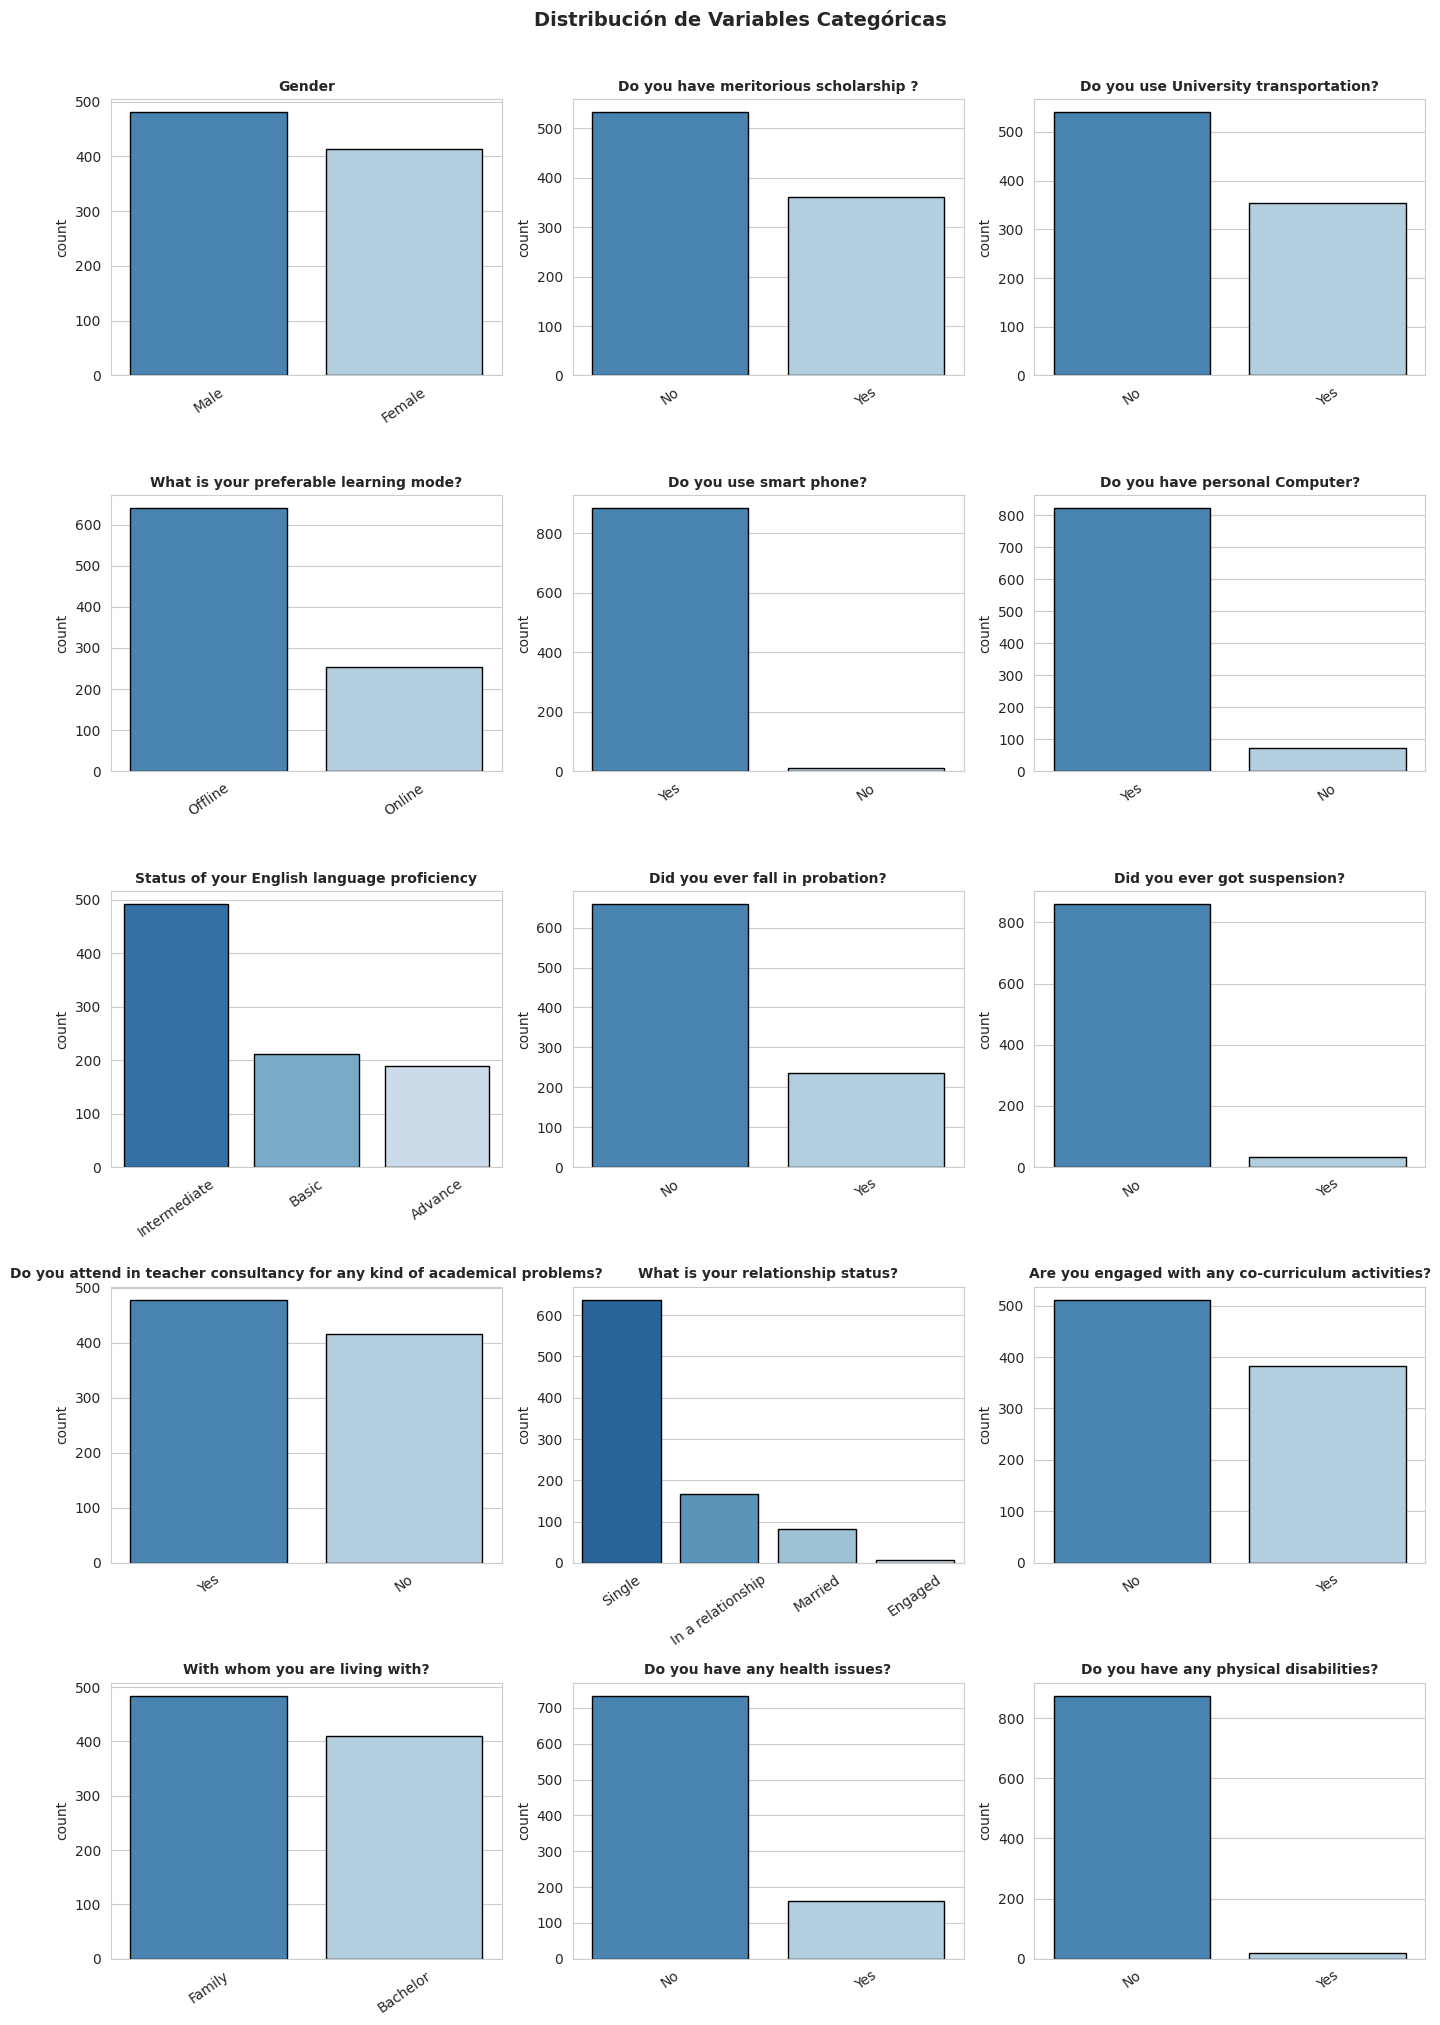

In [10]:
n_cols = 3
n_filas = int(np.ceil(len(categoricas) / n_cols))
fig, axes = plt.subplots(n_filas, n_cols, figsize=(14, 4 * n_filas))
axes = axes.flatten()

for i, var in enumerate(categoricas):
    order = df[var].value_counts().index
    sns.countplot(data=df.dropna(subset=[var]), x=var, order=order, ax=axes[i],
                  palette='Blues_r', edgecolor='black')
    axes[i].set_title(var, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=35)

# Ocultar ejes sobrantes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribución de Variables Categóricas', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 5.2 Correlación con CGPA (variables categóricas codificadas)

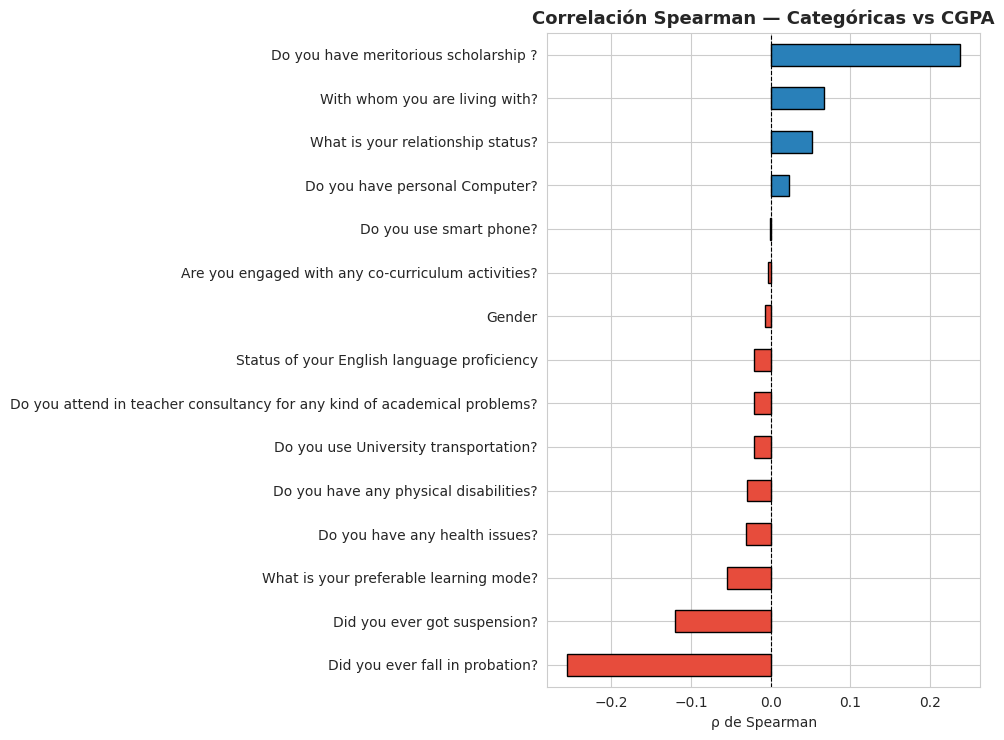

In [11]:
df_cat_corr = df[categoricas + [TARGET]].dropna().copy()

for col in categoricas:
    df_cat_corr[col] = LabelEncoder().fit_transform(df_cat_corr[col])

corr_cat = (df_cat_corr
            .corr(method='spearman')[TARGET]
            .drop(TARGET)
            .sort_values()
)

colors = ['#e74c3c' if v < 0 else '#2980b9' for v in corr_cat]
fig, ax = plt.subplots(figsize=(10, max(4, len(corr_cat) * 0.5)))
corr_cat.plot(kind='barh', color=colors, edgecolor='black', ax=ax)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Correlación Spearman — Categóricas vs CGPA', fontsize=13, fontweight='bold')
ax.set_xlabel('ρ de Spearman')
plt.tight_layout()
plt.show()

### 5.3 Boxplots CGPA por categoría

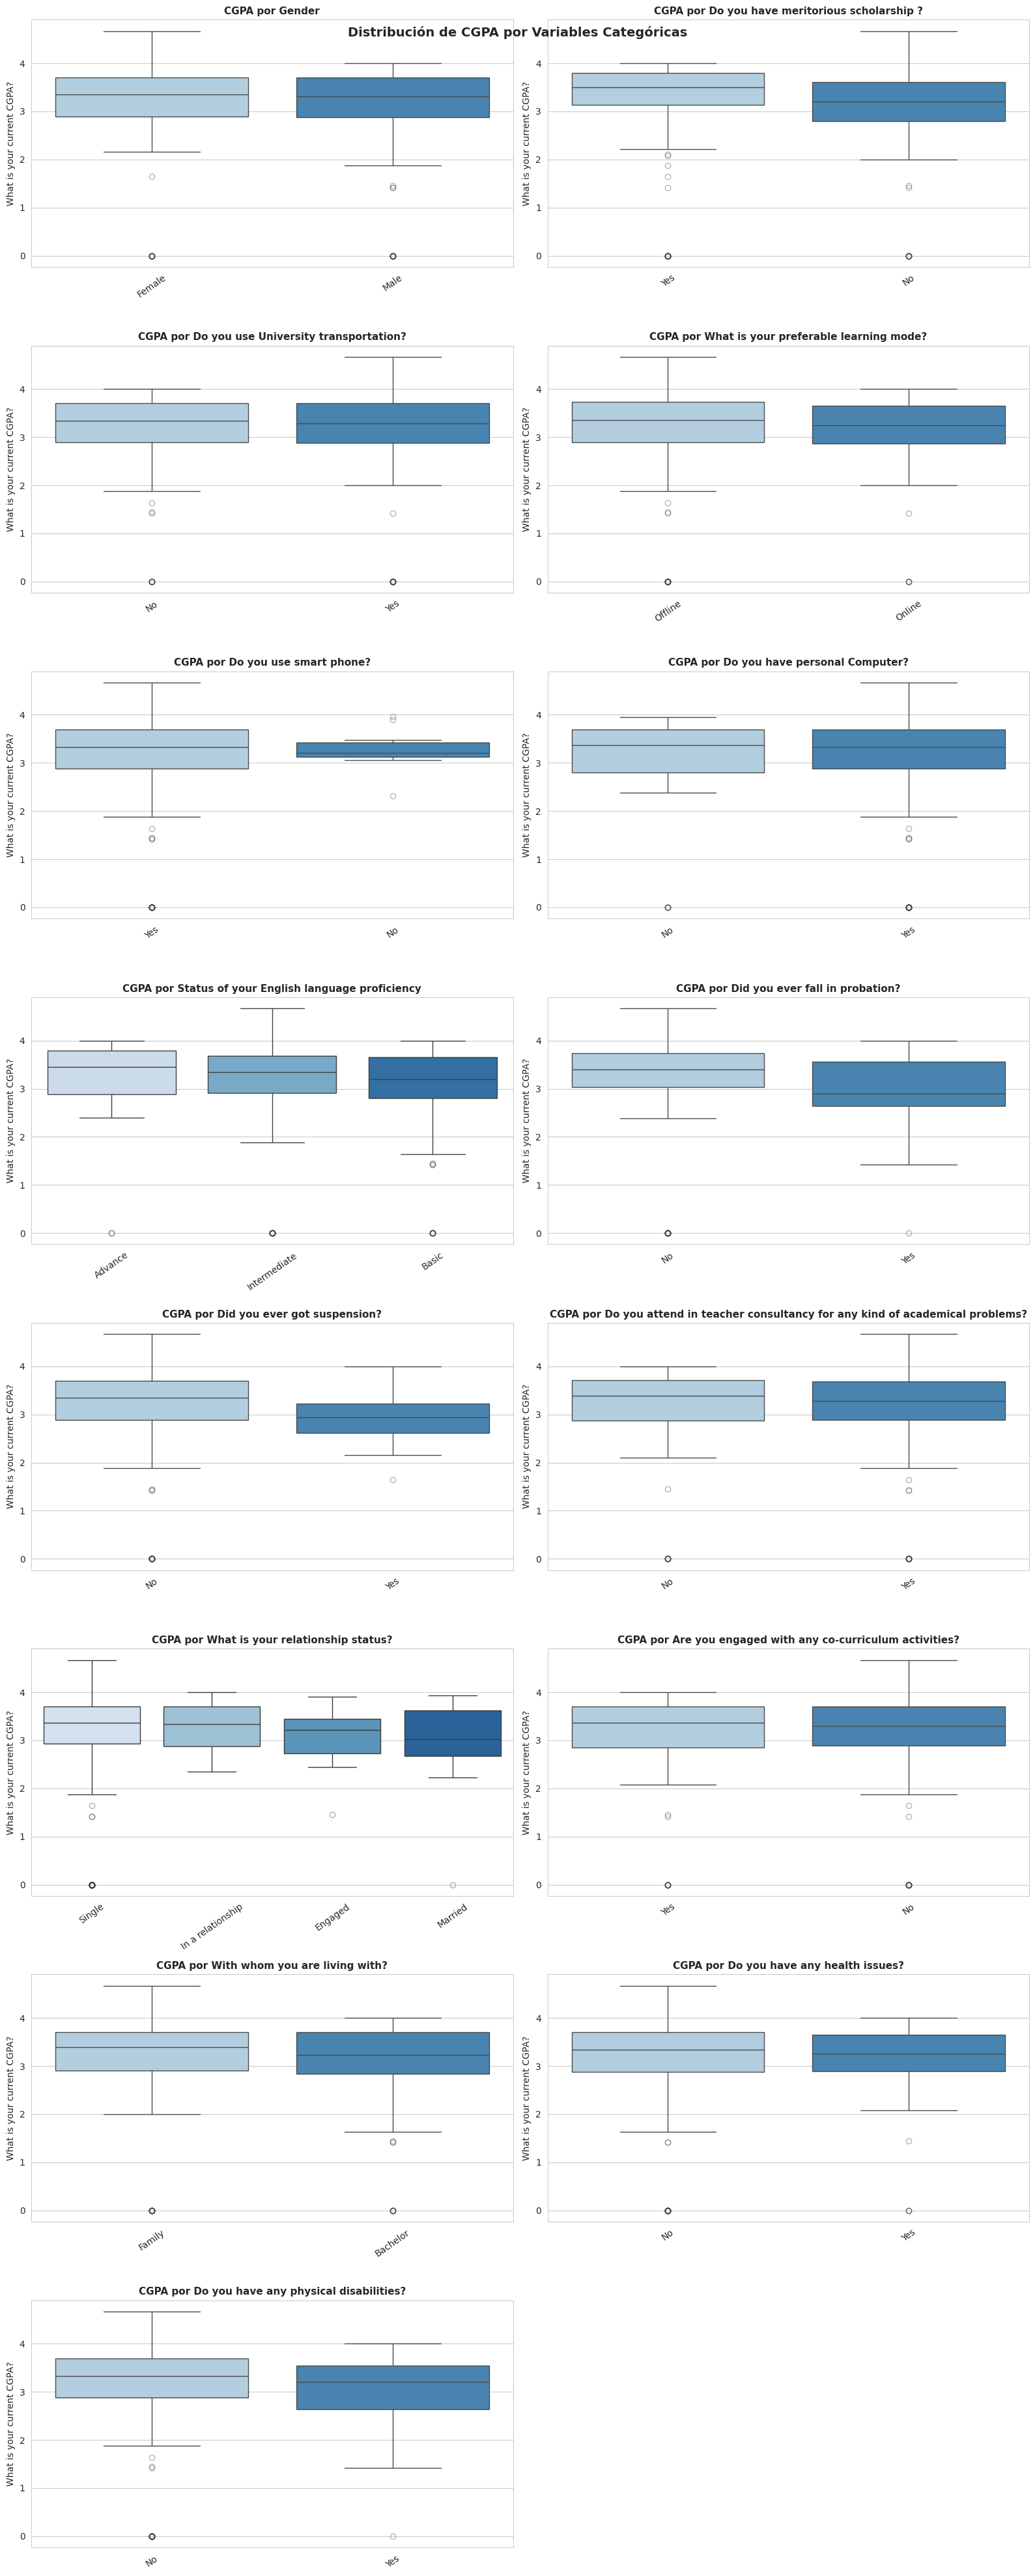

In [12]:
n_cols = 2
n_filas = int(np.ceil(len(categoricas) / n_cols))
fig, axes = plt.subplots(n_filas, n_cols, figsize=(16, 5 * n_filas))
axes = axes.flatten()

for i, var in enumerate(categoricas):
    temp = df[[var, TARGET]].dropna()
    if temp.empty:
        axes[i].set_visible(False)
        continue
    order = temp.groupby(var)[TARGET].median().sort_values(ascending=False).index
    sns.boxplot(data=temp, x=var, y=TARGET, order=order,
                palette='Blues', flierprops=dict(marker='o', alpha=0.4), ax=axes[i])
    axes[i].set_title(f'CGPA por {var}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=35)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribución de CGPA por Variables Categóricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Análisis de variables numéricas

### 6.1 Estadísticas descriptivas

In [13]:
def describir_numericas(df: pd.DataFrame, variables: list) -> pd.DataFrame:
    """Devuelve un resumen descriptivo ampliado para las variables indicadas."""
    registros = []
    for var in variables:
        s = df[var].dropna()
        Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
        registros.append({
            'Variable': var,
            'n': len(s),
            'Media': s.mean(),
            'Mediana': s.median(),
            'Std': s.std(),
            'Varianza': s.var(),
            'Q1': Q1,
            'Q3': Q3,
            'IQR': Q3 - Q1,
            'Min': s.min(),
            'Max': s.max(),
        })
    return pd.DataFrame(registros).set_index('Variable').round(4)

display(describir_numericas(df, numericas))

,n,Media,Mediana,Std,Varianza,Q1,Q3,IQR,Min,Max
Variable,,,,,,,,,,
University Admission year,894,2020.5123,2021.0000,1.2923,1.670100e+00,2020.00,2021.75,1.75,2013.0,2023.00
Age (Years),894,21.3546,21.0000,1.6037,2.571800e+00,20.00,22.00,2.00,18.0,26.00
H.S.C passing year,894,2019.2665,2020.0000,1.3100,1.716200e+00,2019.00,2020.00,1.00,2012.0,2022.00
Current Semester,894,6.4430,7.0000,3.3735,1.138030e+01,3.00,9.00,6.00,1.0,12.00
How many hour do you study daily? (Hours ),894,3.2293,3.0000,2.0871,4.356100e+00,2.00,4.00,2.00,0.0,30.00
How many times do you seat for study in a day?,894,2.1230,2.0000,1.4395,2.072200e+00,1.00,3.00,2.00,0.0,30.00
How many hour do you spent daily in social media? (Hours),894,3.7472,3.0000,3.6334,1.320140e+01,2.00,4.00,2.00,0.0,45.00
Average attendance on class (Percentage ),894,87.3893,95.0000,16.8837,2.850577e+02,80.00,100.00,20.00,0.0,100.00
How many hour do you spent daily on your skill development? (Hours ),894,2.3546,2.0000,2.3512,5.528100e+00,1.00,3.00,2.00,0.0,30.00


### 6.2 Detección de outliers (IQR)

In [14]:
def resumen_outliers(df: pd.DataFrame, variables: list) -> pd.DataFrame:
    registros = []
    for var in variables:
        s = df[var].dropna()
        Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
        IQR = Q3 - Q1
        lb, ub = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        n_out = ((s < lb) | (s > ub)).sum()
        registros.append({'Variable': var, 'N_Outliers': n_out,
                          'Límite_inf': round(lb, 4), 'Límite_sup': round(ub, 4),
                          '% Outliers': round(n_out / len(s) * 100, 2)})
    return pd.DataFrame(registros).set_index('Variable')

display(resumen_outliers(df, numericas))

,N_Outliers,Límite_inf,Límite_sup,% Outliers
Variable,,,,
University Admission year,13,2017.375,2024.375,1.45
Age (Years),6,17.000,25.000,0.67
H.S.C passing year,85,2017.500,2021.500,9.51
Current Semester,0,-6.000,18.000,0.00
How many hour do you study daily? (Hours ),16,-1.000,7.000,1.79
How many times do you seat for study in a day?,8,-2.000,6.000,0.89
How many hour do you spent daily in social media? (Hours),75,-1.000,7.000,8.39
Average attendance on class (Percentage ),36,50.000,130.000,4.03
How many hour do you spent daily on your skill development? (Hours ),10,-2.000,6.000,1.12


### 6.3 Histogramas

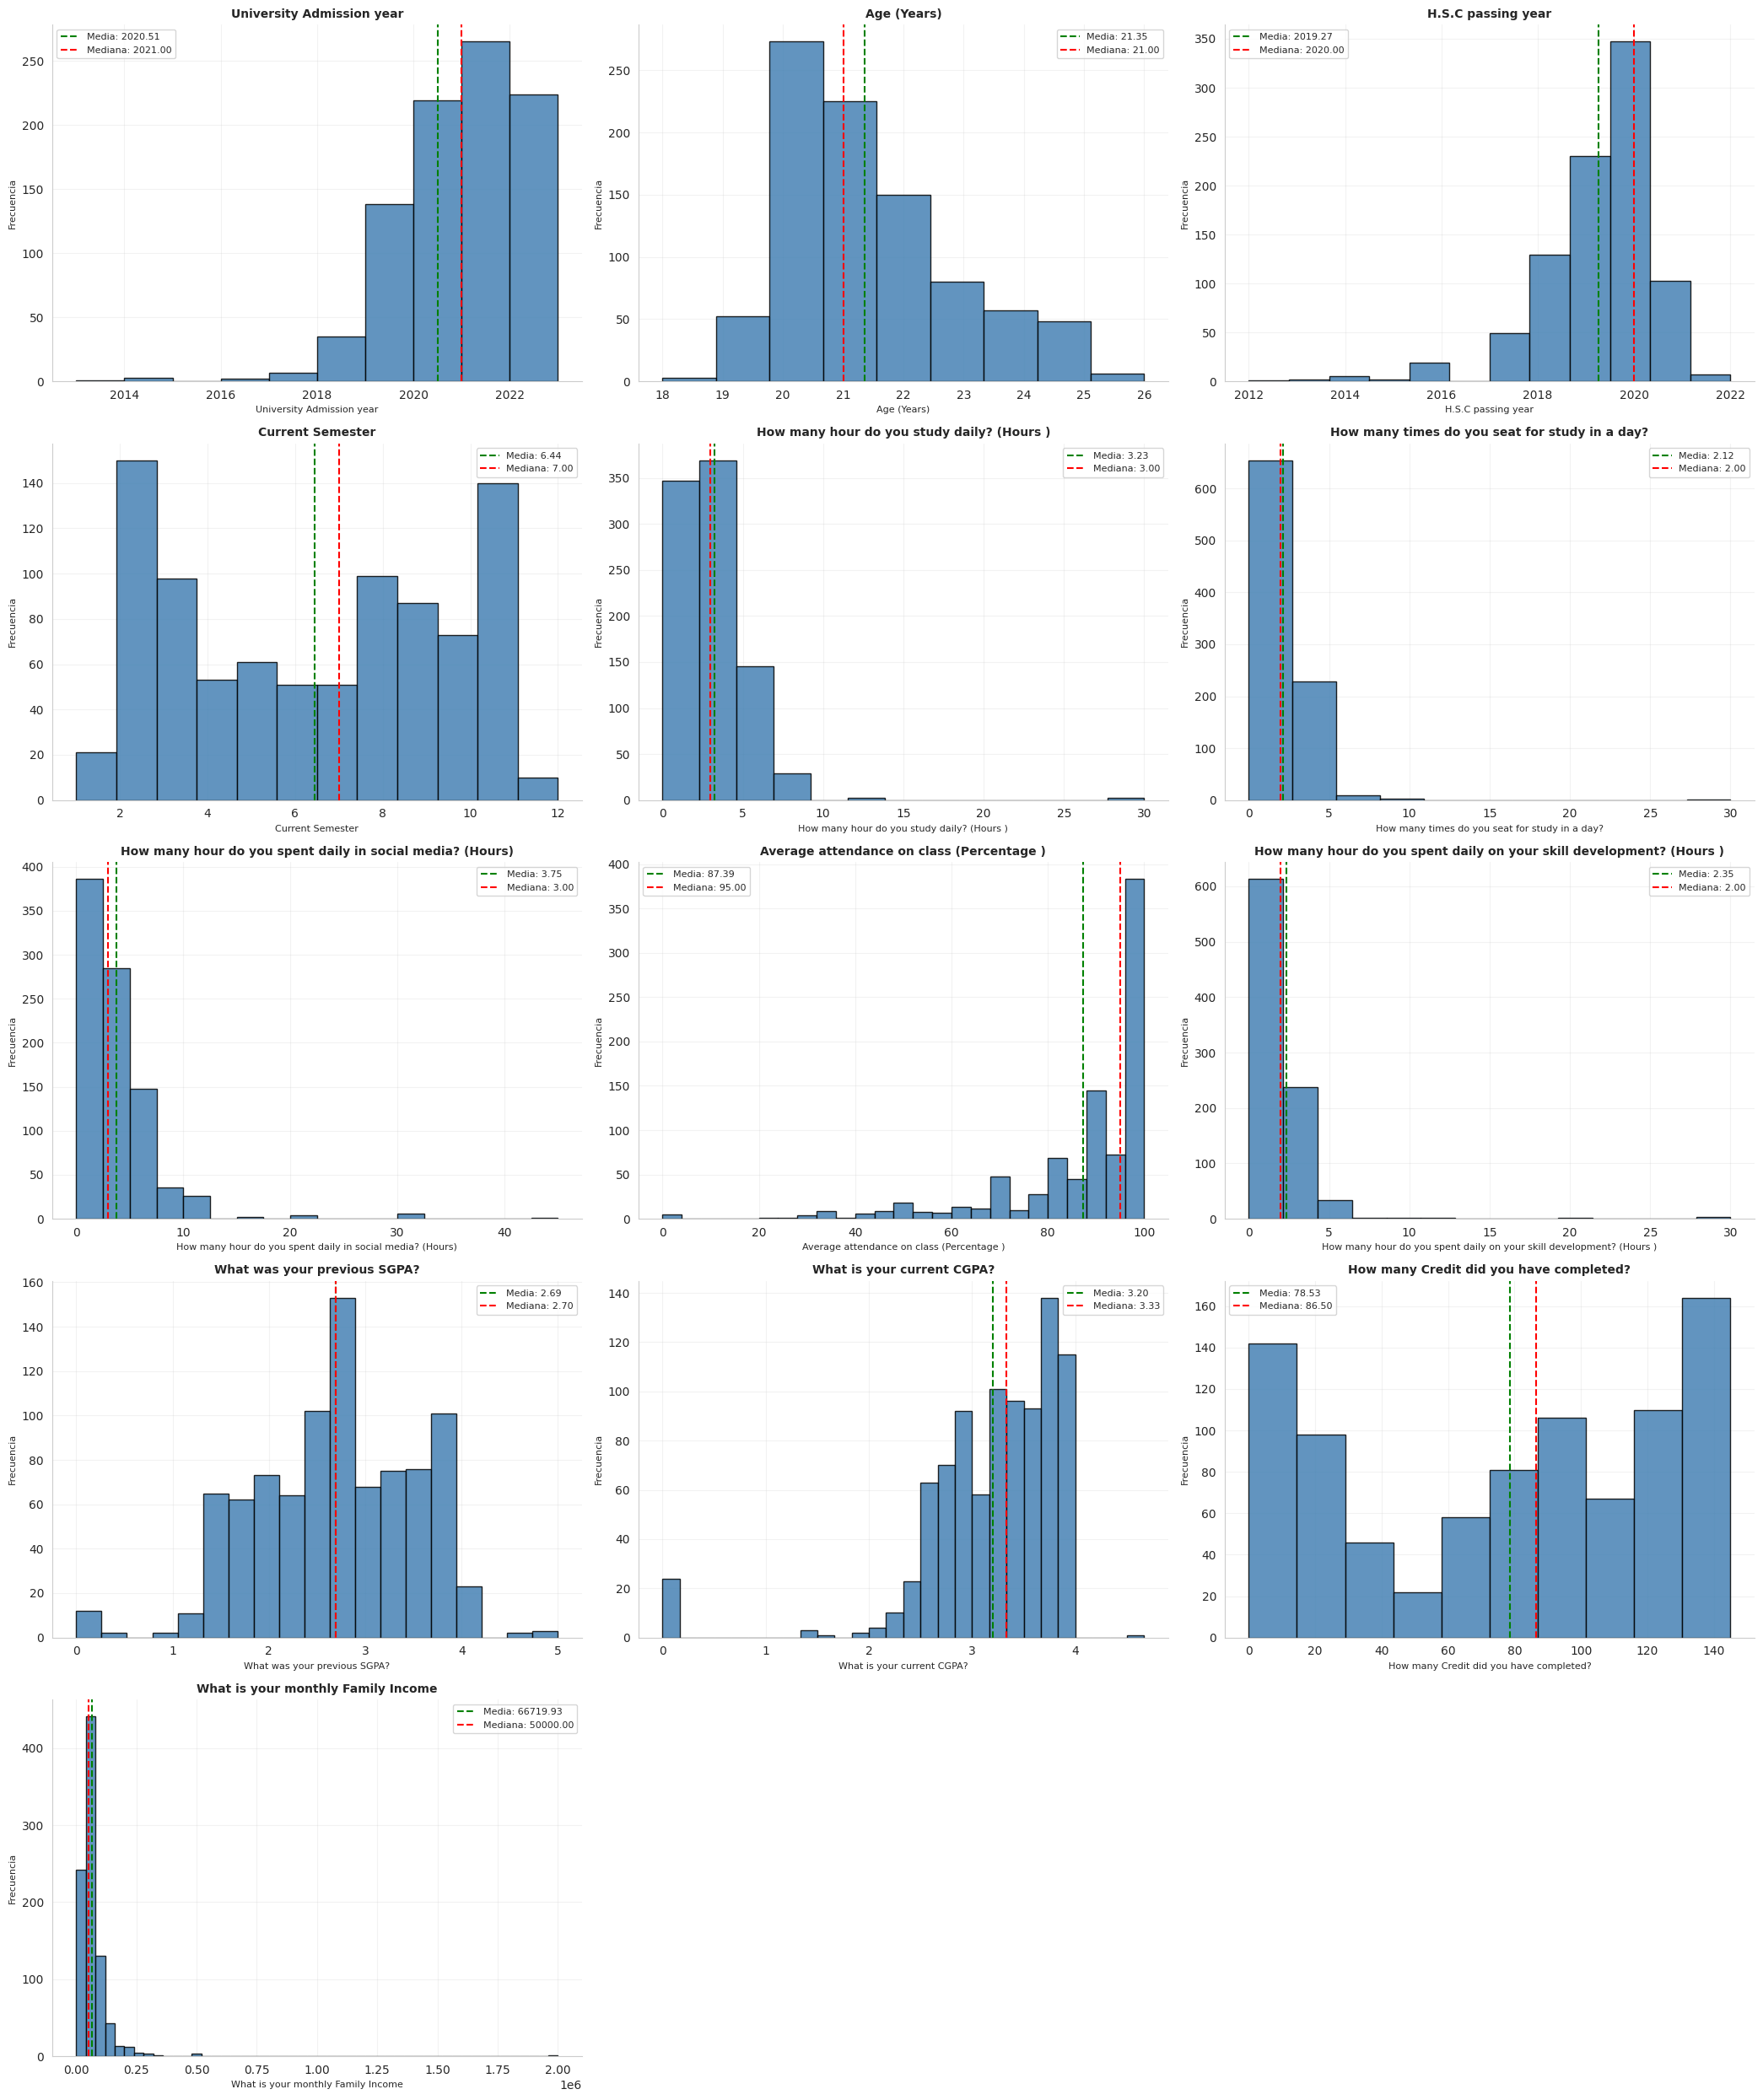

In [15]:
def _bins_optimos(data: pd.Series) -> int:
    """Calcula bins con regla de Freedman-Diaconis, acotado entre 10 y 50."""
    if data.nunique() <= 20:
        return data.nunique()
    q75, q25 = np.percentile(data, [75, 25])
    iqr = q75 - q25
    if iqr == 0:
        return 20
    bw = 2 * iqr / len(data) ** (1 / 3)
    return int(np.clip(np.ceil((data.max() - data.min()) / bw), 10, 50))


def histogramas_matriz(df: pd.DataFrame, variables: list, sin_outliers: bool = True,
                       color: str = 'steelblue', n_cols: int = 3) -> None:
    n_filas = int(np.ceil(len(variables) / n_cols))
    fig, axes = plt.subplots(n_filas, n_cols, figsize=(7 * n_cols, 5 * n_filas))
    axes = axes.flatten()

    for i, col in enumerate(variables):
        ax = axes[i]
        data = df[col].dropna()
        Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
        IQR = Q3 - Q1
        lb, ub = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        data_plot = data[(data >= lb) & (data <= ub)] if sin_outliers else data
        n_out = len(data) - len(data_plot)

        ax.hist(data_plot, bins=_bins_optimos(data_plot), color=color,
                edgecolor='black', alpha=0.85)
        ax.axvline(data.mean(),   color='green', linestyle='--', lw=1.5,
                   label=f'Media: {data.mean():.2f}')
        ax.axvline(data.median(), color='red',   linestyle='--', lw=1.5,
                   label=f'Mediana: {data.median():.2f}')

        sufijo = f"\n(sin {n_out} outliers)" if sin_outliers and n_out else ""
        ax.set_title(f"{col}{sufijo}", fontsize=10, fontweight='bold')
        ax.set_xlabel(col, fontsize=8)
        ax.set_ylabel('Frecuencia', fontsize=8)
        ax.legend(fontsize=8)
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(True, alpha=0.25)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()


histogramas_matriz(df, numericas, sin_outliers=False)

### 6.4 Correlaciones con CGPA

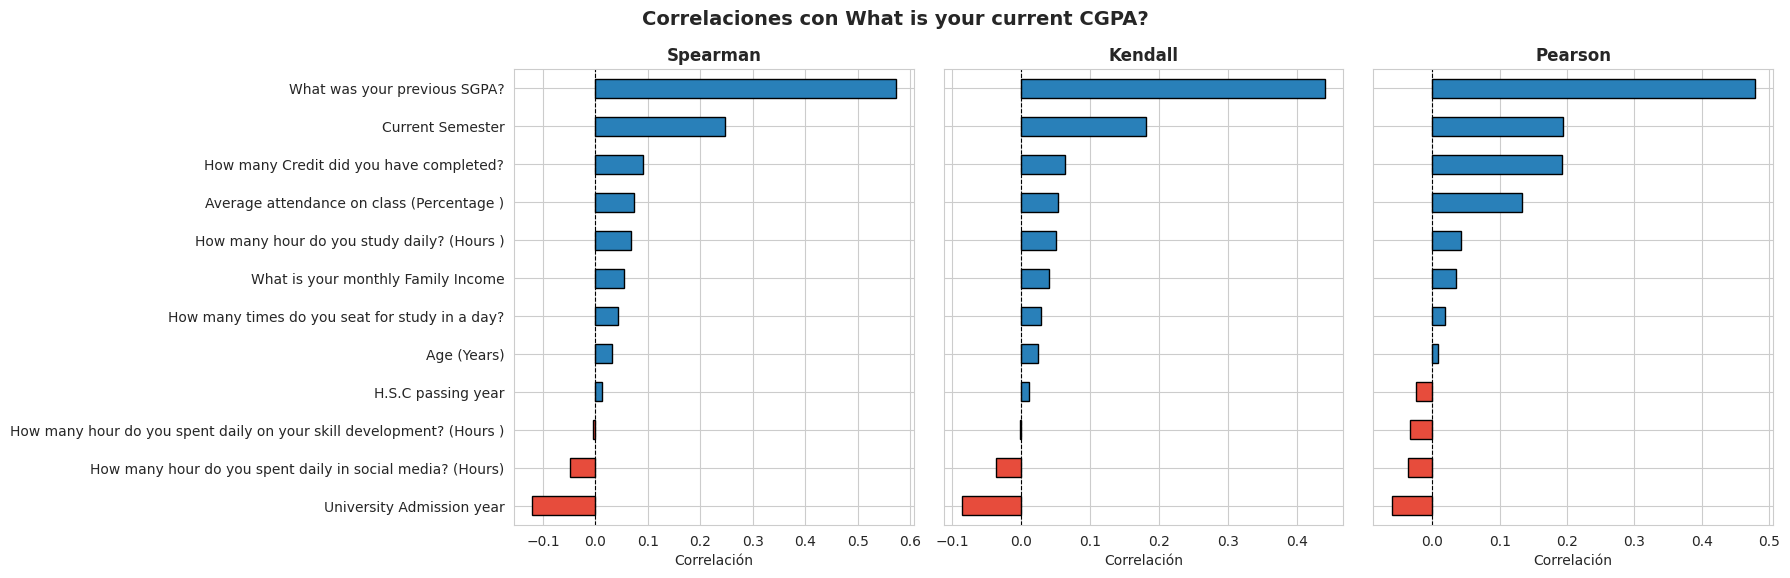

In [16]:
df_num = df[numericas].dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, max(5, len(numericas) * 0.45)), sharey=True)
metodos = ['spearman', 'kendall', 'pearson']

for ax, metodo in zip(axes, metodos):
    corr = df_num.corr(method=metodo)[TARGET].drop(TARGET).sort_values()
    colors = ['#e74c3c' if v < 0 else '#2980b9' for v in corr]
    corr.plot(kind='barh', color=colors, edgecolor='black', ax=ax)
    ax.axvline(0, color='black', lw=0.8, linestyle='--')
    ax.set_title(metodo.capitalize(), fontsize=12, fontweight='bold')
    ax.set_xlabel('Correlación')

fig.suptitle(f'Correlaciones con {TARGET}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.5 Scatter plots vs CGPA

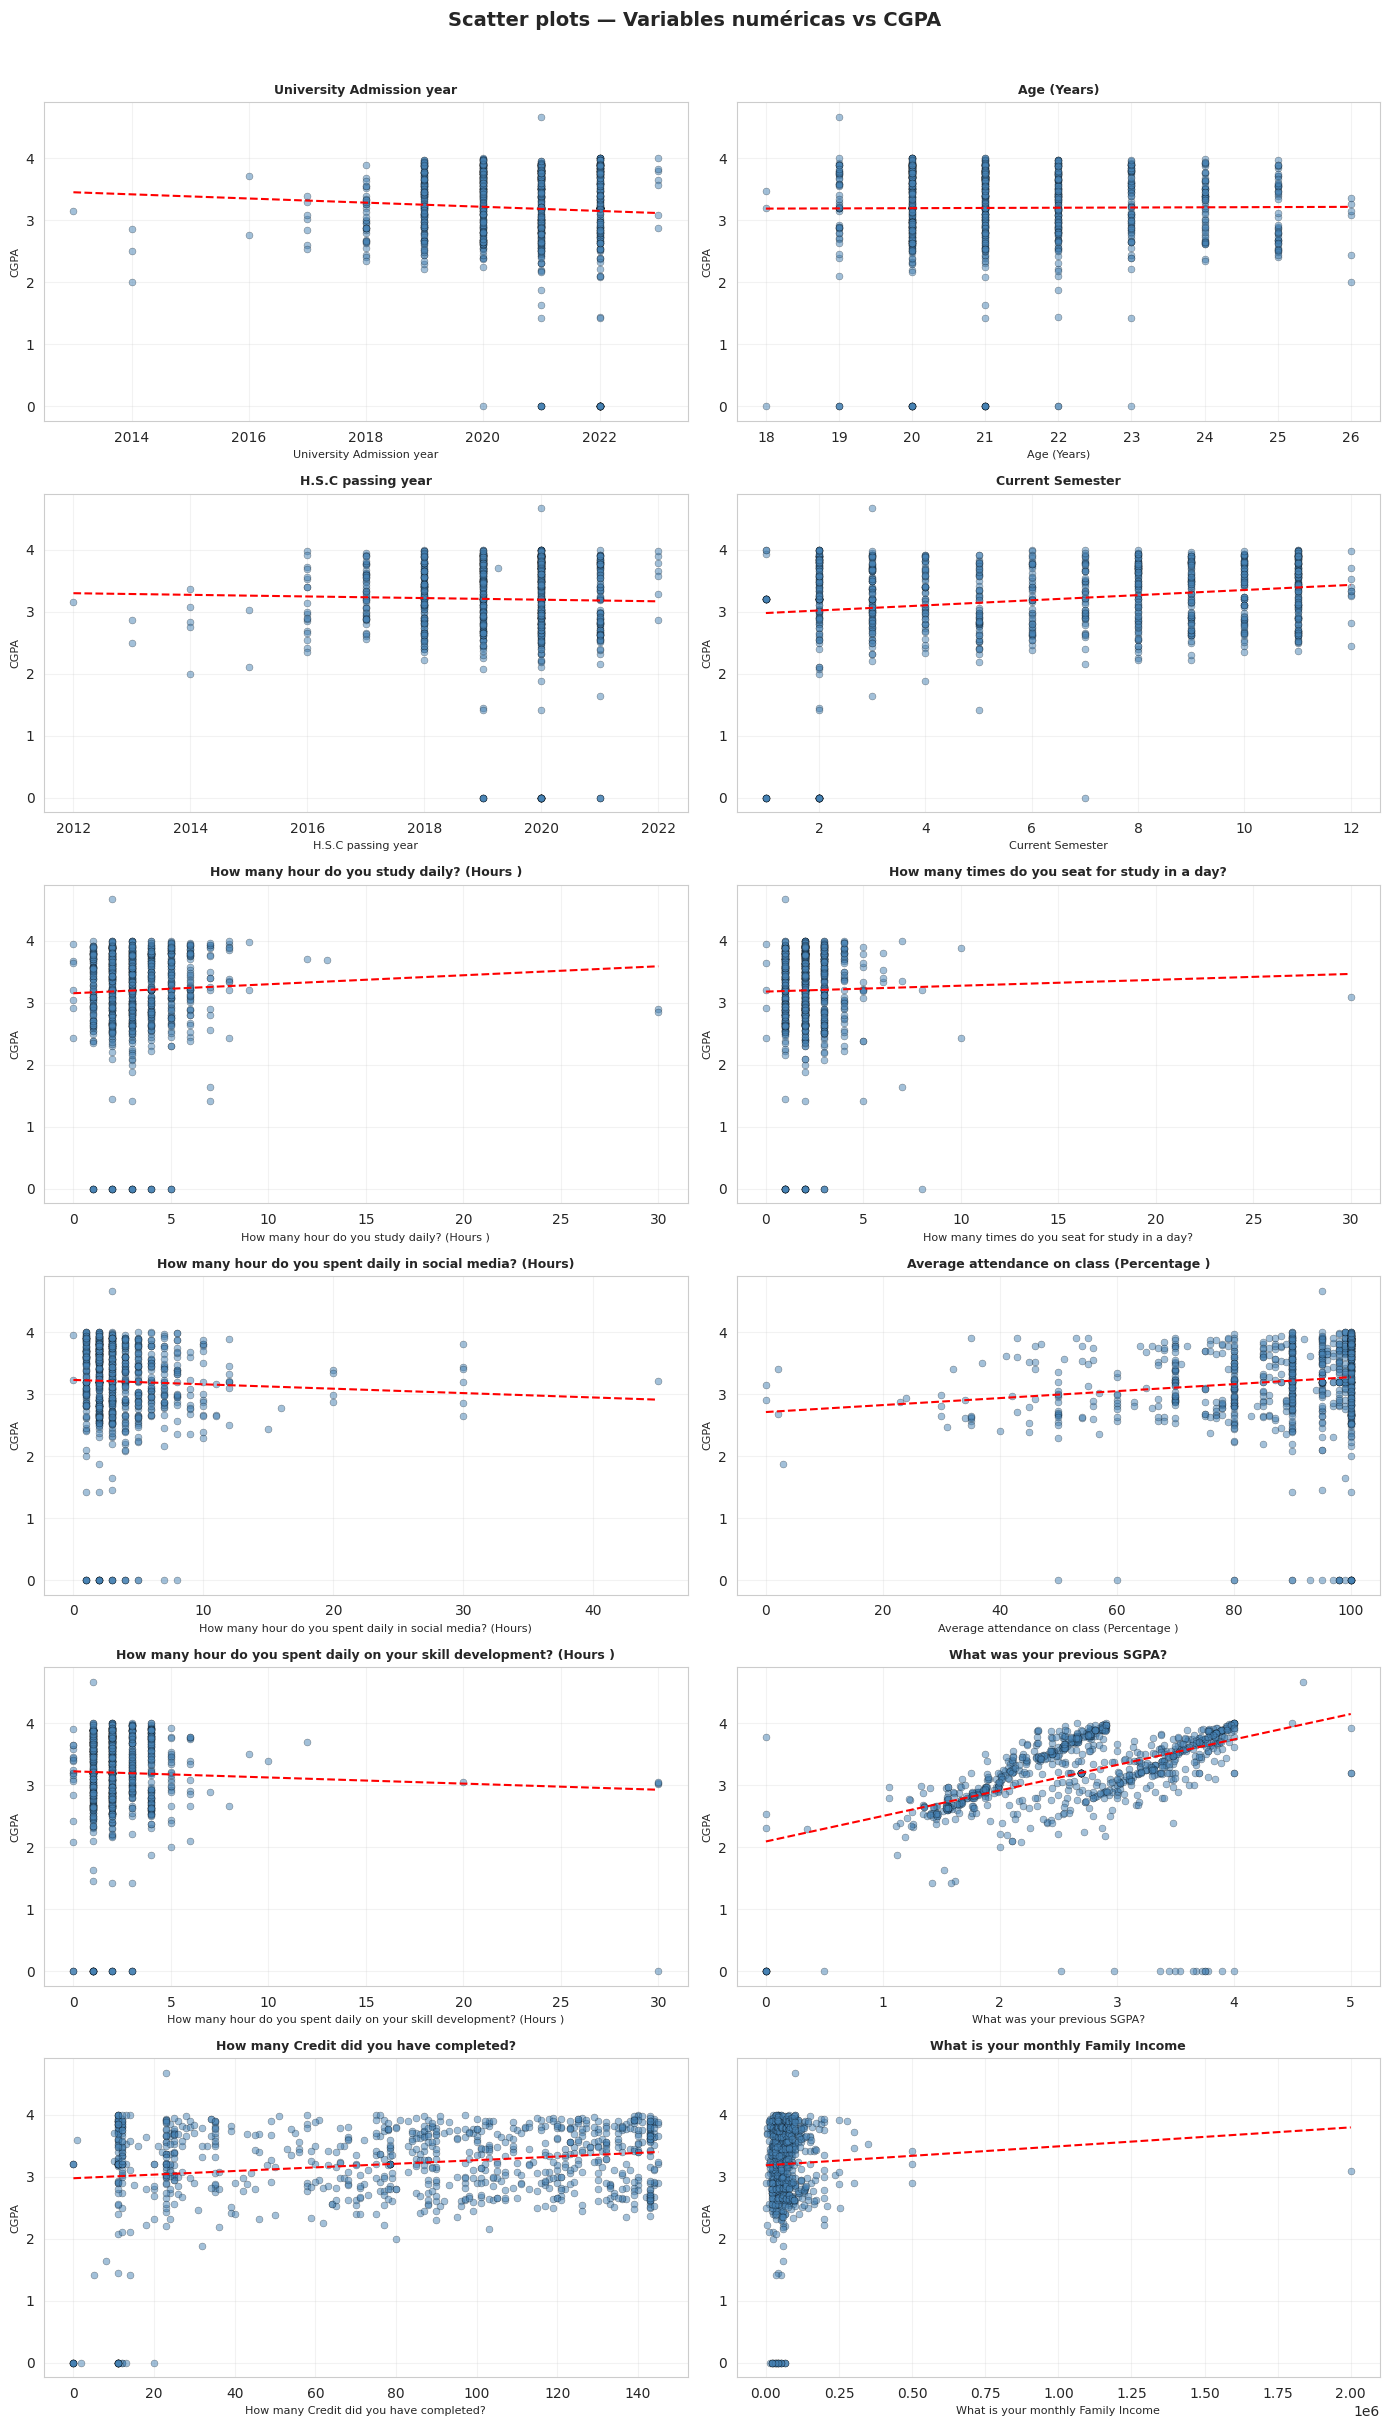

In [17]:
vars_scatter = [v for v in numericas if v != TARGET]
n_cols = 2
n_filas = int(np.ceil(len(vars_scatter) / n_cols))
fig, axes = plt.subplots(n_filas, n_cols, figsize=(14, 4 * n_filas))
axes = axes.flatten()

for i, var in enumerate(vars_scatter):
    temp = df[[var, TARGET]].dropna()
    axes[i].scatter(temp[var], temp[TARGET], alpha=0.5, s=25,
                    color='steelblue', edgecolors='k', linewidths=0.3)
    # Línea de tendencia
    m, b = np.polyfit(temp[var], temp[TARGET], 1)
    xs = np.linspace(temp[var].min(), temp[var].max(), 100)
    axes[i].plot(xs, m * xs + b, color='red', lw=1.5, linestyle='--')
    axes[i].set_title(var, fontsize=9, fontweight='bold')
    axes[i].set_xlabel(var, fontsize=8)
    axes[i].set_ylabel('CGPA', fontsize=8)
    axes[i].grid(True, alpha=0.25)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Scatter plots — Variables numéricas vs CGPA', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Pruebas de asociación y dependencia

### 7.1 Chi-cuadrado (variables categóricas)

In [18]:
def prueba_chi(df: pd.DataFrame, variables: list, alpha: float = 0.05) -> pd.DataFrame:
    """Chi-cuadrado de independencia para todos los pares de variables categóricas."""
    registros = []
    for var1, var2 in combinations(variables, 2):
        tabla = pd.crosstab(df[var1], df[var2])
        chi2, p, dof, _ = chi2_contingency(tabla)
        registros.append({
            'Variable 1': var1,
            'Variable 2': var2,
            'Chi²': round(chi2, 4),
            'p-valor': round(p, 4),
            'gl': dof,
            'Dependencia': '✔ Sí' if p < alpha else '✘ No',
        })
    return pd.DataFrame(registros).sort_values('p-valor').reset_index(drop=True)


def tabla_chi(resultado: pd.DataFrame, alpha: float = 0.05) -> None:
    """Muestra la tabla completa con colores, scroll y resumen de conteos."""
    from IPython.display import display, HTML

    dep  = (resultado['Dependencia'] == '✔ Sí').sum()
    ind  = len(resultado) - dep

    def _color_fila(row):
        bg = '#fde8e8' if row['Dependencia'] == '✔ Sí' else '#e8f8e8'
        return [f'background-color:{bg}'] * len(row)

    def _color_p(val):
        if not isinstance(val, float):
            return ''
        return 'color:#c0392b;font-weight:bold' if val < alpha else 'color:#27ae60;font-weight:bold'

    def _color_dep(val):
        if val == '✔ Sí': return 'color:#c0392b;font-weight:bold'
        if val == '✘ No': return 'color:#27ae60;font-weight:bold'
        return ''

    styled = (
        resultado.style
        .apply(_color_fila, axis=1)
        .applymap(_color_p,  subset=['p-valor'])
        .applymap(_color_dep, subset=['Dependencia'])
        .format({'Chi²': '{:.4f}', 'p-valor': '{:.4f}'})
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-size', '14px'), ('font-weight', 'bold'),
                       ('padding-bottom', '8px'), ('color', '#2c3e50')]},
            {'selector': 'thead th',
             'props': [('background-color', '#2c3e50'), ('color', 'white'),
                       ('font-weight', 'bold'), ('text-align', 'center'),
                       ('padding', '8px 12px'), ('position', 'sticky'),
                       ('top', '0'), ('z-index', '1')]},
            {'selector': 'td',
             'props': [('text-align', 'center'), ('padding', '6px 12px'),
                       ('border-bottom', '1px solid #ddd')]},
            {'selector': 'tr:hover td',
             'props': [('filter', 'brightness(0.94)'), ('cursor', 'default')]},
        ])
        .set_caption(f'Prueba Chi-cuadrado de Independencia — α = {alpha}  '
                     f'| Dependientes: {dep}  |  Independientes: {ind}')
    )

    display(HTML(f"""
        <div style="max-height:520px;overflow-y:auto;overflow-x:auto;
                    border:1px solid #ccc;border-radius:6px;padding:4px;">
            {styled.to_html()}
        </div>
    """))


resultado_chi = prueba_chi(df, categoricas)
tabla_chi(resultado_chi)


,Variable 1,Variable 2,Chi²,p-valor,gl,Dependencia
0,Do you have any health issues?,Do you have any physical disabilities?,30.3023,0.0000,1,✔ Sí
1,What is your relationship status?,With whom you are living with?,57.8942,0.0000,3,✔ Sí
2,Did you ever fall in probation?,What is your relationship status?,46.3967,0.0000,3,✔ Sí
3,Did you ever fall in probation?,Did you ever got suspension?,38.2163,0.0000,1,✔ Sí
4,Do you use University transportation?,With whom you are living with?,54.6187,0.0000,1,✔ Sí
5,Do you have meritorious scholarship ?,What is your relationship status?,45.4917,0.0000,3,✔ Sí
6,Do you have meritorious scholarship ?,Did you ever fall in probation?,33.9720,0.0000,1,✔ Sí
7,Gender,With whom you are living with?,26.6704,0.0000,1,✔ Sí
8,Gender,What is your relationship status?,20.1089,0.0002,3,✔ Sí
9,Do you have meritorious scholarship ?,Do you use University transportation?,13.2799,0.0003,1,✔ Sí


### 7.2 Spearman (variables numéricas)

In [19]:
def prueba_spearman(df: pd.DataFrame, variables: list, alpha: float = 0.05) -> pd.DataFrame:
    """Correlación de Spearman para todos los pares de variables numéricas."""
    def _fuerza(coef):
        a = abs(coef)
        if a < 0.3: return 'Débil'
        if a < 0.7: return 'Moderada'
        return 'Fuerte'

    registros = []
    for var1, var2 in combinations(variables, 2):
        temp = df[[var1, var2]].dropna()
        coef, p = spearmanr(temp[var1], temp[var2])
        registros.append({
            'Variable 1': var1,
            'Variable 2': var2,
            'ρ': round(coef, 5),
            '|ρ|': round(abs(coef), 5),
            'Fuerza': _fuerza(coef),
            'Dirección': 'Positiva' if coef >= 0 else 'Negativa',
            'p-valor': round(p, 4),
            'Asociación': '✔ Sí' if p < alpha else '✘ No',
        })
    return pd.DataFrame(registros).sort_values('p-valor').reset_index(drop=True)


def tabla_spearman(resultado: pd.DataFrame, alpha: float = 0.05) -> None:
    """Muestra la tabla completa con colores, scroll y resumen de conteos."""
    from IPython.display import display, HTML

    asoc = (resultado['Asociación'] == '✔ Sí').sum()
    no   = len(resultado) - asoc

    def _color_fila(row):
        bg = '#fde8e8' if row['Asociación'] == '✔ Sí' else '#e8f8e8'
        return [f'background-color:{bg}'] * len(row)

    def _color_p(val):
        if not isinstance(val, float): return ''
        return 'color:#c0392b;font-weight:bold' if val < alpha else 'color:#27ae60;font-weight:bold'

    def _color_asoc(val):
        if val == '✔ Sí': return 'color:#c0392b;font-weight:bold'
        if val == '✘ No': return 'color:#27ae60;font-weight:bold'
        return ''

    styled = (
        resultado.style
        .apply(_color_fila, axis=1)
        .applymap(_color_p,    subset=['p-valor'])
        .applymap(_color_asoc, subset=['Asociación'])
        .format({'ρ': '{:.5f}', '|ρ|': '{:.5f}', 'p-valor': '{:.4f}'})
        .background_gradient(subset=['|ρ|'], cmap='Blues')
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-size', '14px'), ('font-weight', 'bold'),
                       ('padding-bottom', '8px'), ('color', '#2c3e50')]},
            {'selector': 'thead th',
             'props': [('background-color', '#2c3e50'), ('color', 'white'),
                       ('font-weight', 'bold'), ('text-align', 'center'),
                       ('padding', '8px 12px'), ('position', 'sticky'),
                       ('top', '0'), ('z-index', '1')]},
            {'selector': 'td',
             'props': [('text-align', 'center'), ('padding', '6px 12px'),
                       ('border-bottom', '1px solid #ddd')]},
            {'selector': 'tr:hover td',
             'props': [('filter', 'brightness(0.94)')]},
        ])
        .set_caption(f'Correlación de Spearman — α = {alpha}  '
                     f'| Con asociación: {asoc}  |  Sin asociación: {no}')
    )

    display(HTML(f"""
        <div style="max-height:520px;overflow-y:auto;overflow-x:auto;
                    border:1px solid #ccc;border-radius:6px;padding:4px;">
            {styled.to_html()}
        </div>
    """))


resultado_spearman = prueba_spearman(df, numericas)
tabla_spearman(resultado_spearman)


,Variable 1,Variable 2,ρ,|ρ|,Fuerza,Dirección,p-valor,Asociación
0,University Admission year,Age (Years),-0.58437,0.58437,Moderada,Negativa,0.0000,✔ Sí
1,H.S.C passing year,What was your previous SGPA?,-0.18509,0.18509,Débil,Negativa,0.0000,✔ Sí
2,H.S.C passing year,How many Credit did you have completed?,-0.36208,0.36208,Moderada,Negativa,0.0000,✔ Sí
3,H.S.C passing year,What is your monthly Family Income,0.15119,0.15119,Débil,Positiva,0.0000,✔ Sí
4,Current Semester,How many hour do you spent daily on your skill development? (Hours ),0.19330,0.19330,Débil,Positiva,0.0000,✔ Sí
5,Current Semester,How many Credit did you have completed?,0.83959,0.83959,Fuerte,Positiva,0.0000,✔ Sí
6,Current Semester,What is your monthly Family Income,0.32753,0.32753,Moderada,Positiva,0.0000,✔ Sí
7,How many hour do you study daily? (Hours ),How many times do you seat for study in a day?,0.41070,0.41070,Moderada,Positiva,0.0000,✔ Sí
8,H.S.C passing year,Current Semester,-0.38693,0.38693,Moderada,Negativa,0.0000,✔ Sí
9,How many hour do you study daily? (Hours ),Average attendance on class (Percentage ),0.16490,0.16490,Débil,Positiva,0.0000,✔ Sí


### 7.3 Kruskal-Wallis (numérica × categórica)

In [20]:
def prueba_kruskal(df: pd.DataFrame, numericas: list, categoricas: list,
                   alpha: float = 0.05) -> pd.DataFrame:
    """Kruskal-Wallis para todos los pares (numérica × categórica)."""
    def _efecto(eps):
        if eps < 0.01: return 'Despreciable'
        if eps < 0.08: return 'Pequeño'
        if eps < 0.26: return 'Moderado'
        return 'Grande'

    n_obs = len(df)
    registros = []
    for var_num, var_cat in product(numericas, categoricas):
        grupos = [df[var_num][df[var_cat] == cat].dropna()
                  for cat in df[var_cat].dropna().unique()]
        grupos = [g for g in grupos if len(g) > 0]
        if len(grupos) < 2:
            continue
        k = len(grupos)
        h, p = kruskal(*grupos)
        eps = max(0, (h - k + 1) / (n_obs - k))
        registros.append({
            'Numérica': var_num,
            'Categórica': var_cat,
            'H': round(h, 4),
            'p-valor': round(p, 4),
            'ε²': round(eps, 4),
            'Tamaño efecto': _efecto(eps),
            'Diferencias': '✔ Sí' if p < alpha else '✘ No',
        })
    return pd.DataFrame(registros).sort_values('p-valor').reset_index(drop=True)


def tabla_kruskal(resultado: pd.DataFrame, alpha: float = 0.05) -> None:
    """Muestra la tabla completa con colores, scroll y resumen de conteos."""
    from IPython.display import display, HTML

    sig  = (resultado['Diferencias'] == '✔ Sí').sum()
    no   = len(resultado) - sig

    _EFECTO_COLOR = {
        'Despreciable': '#95a5a6',
        'Pequeño':      '#3498db',
        'Moderado':     '#e67e22',
        'Grande':       '#e74c3c',
    }

    def _color_fila(row):
        bg = '#fde8e8' if row['Diferencias'] == '✔ Sí' else '#e8f8e8'
        return [f'background-color:{bg}'] * len(row)

    def _color_p(val):
        if not isinstance(val, float): return ''
        return 'color:#c0392b;font-weight:bold' if val < alpha else 'color:#27ae60;font-weight:bold'

    def _color_dif(val):
        if val == '✔ Sí': return 'color:#c0392b;font-weight:bold'
        if val == '✘ No': return 'color:#27ae60;font-weight:bold'
        return ''

    def _color_efecto(val):
        return f'color:{_EFECTO_COLOR.get(val, "black")};font-weight:bold'

    styled = (
        resultado.style
        .apply(_color_fila, axis=1)
        .applymap(_color_p,      subset=['p-valor'])
        .applymap(_color_dif,    subset=['Diferencias'])
        .applymap(_color_efecto, subset=['Tamaño efecto'])
        .format({'H': '{:.4f}', 'p-valor': '{:.4f}', 'ε²': '{:.4f}'})
        .background_gradient(subset=['ε²'], cmap='Oranges')
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-size', '14px'), ('font-weight', 'bold'),
                       ('padding-bottom', '8px'), ('color', '#2c3e50')]},
            {'selector': 'thead th',
             'props': [('background-color', '#2c3e50'), ('color', 'white'),
                       ('font-weight', 'bold'), ('text-align', 'center'),
                       ('padding', '8px 12px'), ('position', 'sticky'),
                       ('top', '0'), ('z-index', '1')]},
            {'selector': 'td',
             'props': [('text-align', 'center'), ('padding', '6px 12px'),
                       ('border-bottom', '1px solid #ddd')]},
            {'selector': 'tr:hover td',
             'props': [('filter', 'brightness(0.94)')]},
        ])
        .set_caption(f'Kruskal-Wallis — α = {alpha}  '
                     f'| Con diferencias: {sig}  |  Sin diferencias: {no}')
    )

    display(HTML(f"""
        <div style="max-height:520px;overflow-y:auto;overflow-x:auto;
                    border:1px solid #ccc;border-radius:6px;padding:4px;">
            {styled.to_html()}
        </div>
    """))


resultado_kruskal = prueba_kruskal(df, numericas, categoricas)
tabla_kruskal(resultado_kruskal)


,Numérica,Categórica,H,p-valor,ε²,Tamaño efecto,Diferencias
0,What is your monthly Family Income,Gender,25.8447,0.0000,0.0279,Pequeño,✔ Sí
1,What was your previous SGPA?,Did you ever fall in probation?,72.2505,0.0000,0.0799,Pequeño,✔ Sí
2,What was your previous SGPA?,Status of your English language proficiency,21.5751,0.0000,0.0220,Pequeño,✔ Sí
3,What is your monthly Family Income,Do you have meritorious scholarship ?,59.0980,0.0000,0.0651,Pequeño,✔ Sí
4,What was your previous SGPA?,What is your relationship status?,82.7771,0.0000,0.0896,Moderado,✔ Sí
5,What is your current CGPA?,Do you have meritorious scholarship ?,50.5024,0.0000,0.0555,Pequeño,✔ Sí
6,Average attendance on class (Percentage ),What is your relationship status?,22.6960,0.0000,0.0221,Pequeño,✔ Sí
7,What is your monthly Family Income,Status of your English language proficiency,45.2536,0.0000,0.0485,Pequeño,✔ Sí
8,How many Credit did you have completed?,What is your relationship status?,98.4438,0.0000,0.1072,Moderado,✔ Sí
9,How many Credit did you have completed?,Status of your English language proficiency,107.5802,0.0000,0.1185,Moderado,✔ Sí
